# Paso 4 — Búsqueda con embeddings

BM25 dejó el listón en **P@10 = 0,182**, y un diagnóstico preciso de dónde falla:
en cuanto la consulta y la oferta no comparten palabras. «Resolver problemas de
clientes» no encuentra «Customer Support Legend».

Un embedding convierte cada texto en un vector de números, colocado de forma que
**textos con significado parecido quedan cerca** aunque no compartan ni una
palabra. Eso es lo que debería arreglar el problema.

## Lo que este cuaderno decide midiendo

El paso 1 dejó dos preguntas abiertas y aquí se responden con números, no por
costumbre:

1. **¿Sirvió limpiar la plantilla corporativa?** Se compara texto limpio contra
   original.
2. **¿Qué hacer con las ofertas que no caben en el modelo?** Truncar es lo fácil;
   trocear cuesta más. Se mide si compensa.

Y de paso una tercera que surgió sobre la marcha: **¿ayuda darle el título del
puesto al modelo?** La respuesta es que no, y no era lo esperado.


## 0. Preparación

⚠️ **El orden de las importaciones de la celda siguiente no es casual.**

En Windows, importar `pandas` **antes** que `torch` hace que torch falle al
cargar sus DLL:

```
OSError: [WinError 1114] Error en una rutina de inicialización de
biblioteca de vínculos dinámicos (DLL). Error loading ...\torch\lib\c10.dll
```

Las dos librerías traen su propia copia de OpenMP y la primera que se carga deja
a la otra sin poder inicializarse. Importar `sentence-transformers` —que arrastra
torch— **en primer lugar** lo resuelve.

Va contra el orden alfabético habitual, así que queda avisado: **reordenar estas
líneas rompe el cuaderno.**

In [1]:
# El orden importa: torch ANTES que pandas (ver la nota de arriba).
from sentence_transformers import SentenceTransformer  # noqa: E402

import hashlib
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
CACHE = PROCESADO / "cache_embeddings"
RESULTADOS = RAIZ / "resultados"
CACHE.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

pd.set_option("display.width", 190)

corpus = pd.read_parquet(PROCESADO / "corpus_preparado.parquet")
consultas = pd.read_parquet(PROCESADO / "consultas.parquet")
relevantes = {r.equipo: set(r.ids_relevantes) for r in consultas.itertuples()}
ids_corpus = corpus["id"].to_numpy()

print(f"corpus: {len(corpus):,} ofertas · consultas: {len(consultas)}")

C:\Users\Jhon Garcia\Documents\Repositorios\Repositorio - V2\Buscador semántico de ofertas de empleo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corpus: 10,145 ofertas · consultas: 11


---

# 1. El modelo, y una corrección al paso 1

Se usa **`all-MiniLM-L6-v2`**: 384 dimensiones, pequeño y rápido en CPU. Es el
modelo de referencia para esta tarea — no el mejor que existe, pero sí el que
mejor relación da entre calidad y coste, y el punto de partida razonable.

In [2]:
modelo = SentenceTransformer("all-MiniLM-L6-v2")

print(f"dimensiones:      {modelo.get_sentence_embedding_dimension()}")
print(f"máximo de tokens: {modelo.max_seq_length}")

# Regla práctica en inglés: un token viene a ser 0,75 palabras.
limite_palabras = modelo.max_seq_length * 0.75
palabras = corpus["texto_limpio"].str.split().str.len()

print(f"\nEquivale a unas {limite_palabras:.0f} palabras.")
print(f"Mediana de palabras por oferta: {palabras.median():.0f}")
print(f"Ofertas que superan el límite:  {(palabras > limite_palabras).mean()*100:.1f}%")

dimensiones:      384
máximo de tokens: 256



Equivale a unas 192 palabras.
Mediana de palabras por oferta: 360
Ofertas que superan el límite:  83.1%


### La corrección

En el paso 1 escribí que el modelo cortaría «alrededor de las 256–512 palabras» y
que eso afectaba al **49,4 %** de las ofertas.

**Los dos números estaban mal.** El límite real de `all-MiniLM-L6-v2` es de
**256 tokens**, que son unas **192 palabras** — bastante menos de lo que supuse. Y
con ese límite correcto, las ofertas afectadas no son la mitad:

> **El 83,1 % de las ofertas no cabe en el modelo.**

Cinco de cada seis. Truncar deja fuera la mayor parte del corpus, y eso convierte
la pregunta «¿trunco o troceo?» en la decisión central del cuaderno en lugar de
un detalle de implementación.

Es un buen recordatorio de por qué conviene consultar el límite del modelo en
lugar de darlo por sabido.

## 2. Cómo se busca con vectores

Tres pasos:

1. **Codificar cada oferta** una vez, y guardar el vector.
2. **Codificar la consulta** en el momento.
3. **Ordenar por similitud coseno** — el ángulo entre los vectores.

Con los vectores normalizados a longitud 1, la similitud coseno es simplemente el
producto escalar, así que comparar la consulta contra las 10 145 ofertas es **una
multiplicación de matrices**. Por eso más adelante se verá que buscar tarda
milisegundos: lo caro es codificar, y eso se hace una sola vez.

La codificación se guarda en disco. En la primera ejecución tarda unos minutos;
a partir de ahí se reutiliza.

In [3]:
def codificar(textos, nombre):
    """Codifica los textos, reutilizando el resultado guardado si sigue siendo válido.

    La caché se valida con un hash del contenido: si los textos cambian, se
    recalcula sola en lugar de devolver vectores que ya no corresponden.
    """
    textos = list(textos)
    huella = hashlib.md5("\x00".join(textos).encode("utf-8")).hexdigest()[:12]
    npy = CACHE / f"{nombre}.npy"
    meta = CACHE / f"{nombre}.json"

    if npy.exists() and meta.exists():
        guardado = json.loads(meta.read_text())
        if guardado.get("huella") == huella and guardado.get("n") == len(textos):
            print(f"  {nombre:24} reutilizado de la caché ({len(textos):,} textos)")
            return np.load(npy)

    inicio = time.perf_counter()
    vectores = modelo.encode(textos, batch_size=64, normalize_embeddings=True,
                             convert_to_numpy=True, show_progress_bar=False)
    segundos = time.perf_counter() - inicio
    np.save(npy, vectores)
    meta.write_text(json.dumps({"huella": huella, "n": len(textos),
                                "segundos": round(segundos, 1)}))
    print(f"  {nombre:24} codificado: {len(textos):,} textos en {segundos:.0f} s")
    return vectores

In [4]:
def precision_en_k(ranking, rel, k=10):
    return sum(1 for i in ranking[:k] if i in rel) / k


def recall_en_k(ranking, rel, k=100):
    return sum(1 for i in ranking[:k] if i in rel) / len(rel) if rel else 0.0


def rr(ranking, rel):
    for posicion, i in enumerate(ranking, start=1):
        if i in rel:
            return 1 / posicion
    return 0.0


def ndcg_en_k(ranking, rel, k=10):
    ganancia = sum(1 / np.log2(p + 1) for p, i in enumerate(ranking[:k], start=1) if i in rel)
    ideal = sum(1 / np.log2(p + 1) for p in range(1, min(k, len(rel)) + 1))
    return ganancia / ideal if ideal else 0.0


def evaluar(puntuar, nombre):
    """`puntuar` recibe el vector de la consulta y devuelve una puntuación por oferta."""
    filas, inicio = [], time.perf_counter()
    for fila in consultas.itertuples():
        vector = modelo.encode([fila.consulta], normalize_embeddings=True)[0]
        ranking = ids_corpus[np.argsort(-puntuar(vector))]
        rel = relevantes[fila.equipo]
        filas.append({
            "equipo": fila.equipo,
            "P@10": precision_en_k(ranking, rel),
            "MRR": rr(ranking, rel),
            "nDCG@10": ndcg_en_k(ranking, rel),
            "R@100": recall_en_k(ranking, rel),
        })
    ms = (time.perf_counter() - inicio) / len(consultas) * 1000
    detalle = pd.DataFrame(filas).set_index("equipo")
    return {"variante": nombre, "ms_consulta": round(ms, 1),
            **detalle.mean().round(4).to_dict()}, detalle


print("Métricas listas.")

Métricas listas.


---

# 3. Las cuatro variantes

| | Qué se codifica | Qué pregunta responde |
|---|---|---|
| **A** | Texto limpio, truncado por el modelo | La referencia |
| **B** | Texto original, truncado | ¿Sirvió quitar la plantilla corporativa? |
| **C** | Título + texto limpio, truncado | ¿Ayuda darle el título al modelo? |
| **D** | Texto limpio **troceado** en ventanas | ¿Compensa no truncar? |

En la variante D cada oferta se parte en ventanas de 180 palabras con 40 de
solape —para no cortar una frase por la mitad— y **la puntuación de la oferta es
la de su mejor trozo**. Así una oferta se recupera si *cualquier* parte de ella
encaja con la consulta, aunque el resto hable de otra cosa.

In [5]:
resultados, detalles = [], {}

vectores_a = codificar(corpus["texto_limpio"], "limpio_trunc")
fila, det = evaluar(lambda q: vectores_a @ q, "A · limpio, truncado")
resultados.append(fila); detalles[fila["variante"]] = det

vectores_b = codificar(corpus["descripcion"], "original_trunc")
fila, det = evaluar(lambda q: vectores_b @ q, "B · original, truncado")
resultados.append(fila); detalles[fila["variante"]] = det

textos_c = corpus["titulo"].astype(str) + ". " + corpus["texto_limpio"]
vectores_c = codificar(textos_c, "titulo_limpio_trunc")
fila, det = evaluar(lambda q: vectores_c @ q, "C · título + limpio")
resultados.append(fila); detalles[fila["variante"]] = det

  limpio_trunc             codificado: 10,145 textos en 278 s


  original_trunc           codificado: 10,145 textos en 217 s


  titulo_limpio_trunc      codificado: 10,145 textos en 221 s


In [6]:
VENTANA, SOLAPE = 180, 40

def trocear(textos):
    """Parte cada texto en ventanas solapadas y anota de qué oferta viene cada una."""
    trozos, origen = [], []
    for posicion, texto in enumerate(textos):
        palabras = texto.split()
        if not palabras:
            trozos.append(""); origen.append(posicion)
            continue
        inicio = 0
        while inicio < len(palabras):
            trozos.append(" ".join(palabras[inicio:inicio + VENTANA]))
            origen.append(posicion)
            if inicio + VENTANA >= len(palabras):
                break
            inicio += VENTANA - SOLAPE
    return trozos, np.array(origen)


trozos, de_oferta = trocear(corpus["texto_limpio"])
print(f"{len(corpus):,} ofertas → {len(trozos):,} trozos "
      f"({len(trozos)/len(corpus):.1f} por oferta)\n")

vectores_d = codificar(trozos, f"trozos_{VENTANA}_{SOLAPE}")


def puntuar_por_mejor_trozo(vector):
    """La puntuación de una oferta es la de su trozo que mejor encaja."""
    por_trozo = vectores_d @ vector
    por_oferta = np.full(len(corpus), -np.inf)
    np.maximum.at(por_oferta, de_oferta, por_trozo)
    return por_oferta


fila, det = evaluar(puntuar_por_mejor_trozo, "D · troceado (mejor trozo)")
resultados.append(fila); detalles[fila["variante"]] = det

comparativa = pd.DataFrame(resultados).set_index("variante")
comparativa

10,145 ofertas → 32,629 trozos (3.2 por oferta)



  trozos_180_40            codificado: 32,629 textos en 774 s


,ms_consulta,P@10,MRR,nDCG@10,R@100
variante,,,,,
"A · limpio, truncado",15.6,0.2545,0.2642,0.2233,0.2062
"B · original, truncado",13.9,0.2182,0.3091,0.2127,0.1630
C · título + limpio,13.6,0.2091,0.3222,0.2045,0.1978
D · troceado (mejor trozo),21.3,0.3182,0.4820,0.3115,0.2589


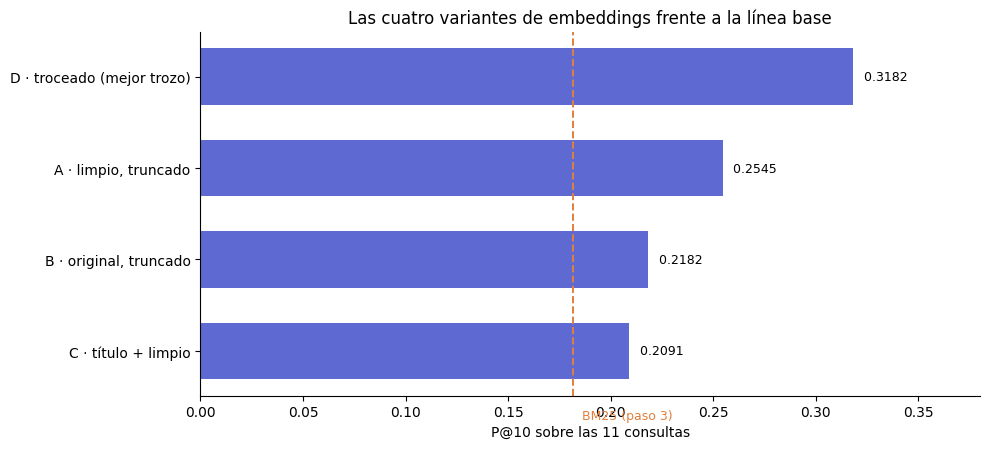

In [7]:
BM25 = {"P@10": 0.1818, "MRR": 0.3245, "nDCG@10": 0.1812, "R@100": 0.2134}

fig, ax = plt.subplots(figsize=(10, 4.6))
orden = comparativa.sort_values("P@10").index
posicion = np.arange(len(orden))

barras = ax.barh(posicion, comparativa.loc[orden, "P@10"], 0.62, color=ACENTO)
ax.axvline(BM25["P@10"], color=AVISO, linestyle="--", linewidth=1.4)
ax.text(BM25["P@10"] + 0.004, -0.75, "BM25 (paso 3)", fontsize=9, color=AVISO)

ax.bar_label(barras, labels=[f"  {v:.4f}" for v in comparativa.loc[orden, "P@10"]],
             padding=2, fontsize=9)
ax.set_yticks(posicion, orden)
ax.set_xlim(0, 0.38)
ax.set_xlabel("P@10 sobre las 11 consultas")
ax.set_title("Las cuatro variantes de embeddings frente a la línea base")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "embeddings-variantes.png", dpi=140)
plt.show()

### Qué se ve aquí

**Las cuatro variantes superan a BM25 en P@10.** La peor (0,209) ya le saca 15 %;
la mejor (0,318) lo multiplica por 1,75.

Tres lecturas, en orden de importancia:

**1. Trocear es la decisión que más pesa.** De 0,2545 (truncado) a **0,3182**
(troceado): un 25 % más. Tiene sentido con el dato del apartado 1 — si el 83 % de
las ofertas no cabe en el modelo, truncar tira la mayor parte del corpus. El
troceado es lo único que le da acceso al texto completo.

**2. Limpiar la plantilla corporativa sirvió, otra vez.** Texto limpio 0,2545
frente a original 0,2182: **+17 %**. En el paso 3 BM25 mejoraba un 18 % con la
misma limpieza. Dos métodos muy distintos coinciden en que aquellos párrafos de
`b.skilled` y `b.responsible` estorbaban.

**3. Añadir el título empeora**, y eso no me lo esperaba: 0,2091 frente a 0,2545,
un 18 % peor.

Sobre el tercero conviene ser honesto: **tengo una hipótesis, no una explicación
demostrada**. Lo más probable es que, con solo 192 palabras de margen, anteponer
el título desplaza texto útil fuera de la ventana; y como muchos títulos son
genéricos (`Senior Manager`, `Analyst II`), se estaría cambiando contenido
descriptivo por ruido. **No lo he comprobado**, y comprobarlo requeriría medir con
el título añadido al final en lugar de al principio.

> **Variante elegida: D — texto limpio, troceado.**

---

# 4. Frente a BM25: no es un barrido

El promedio dice que los embeddings ganan con claridad. Consulta por consulta la
historia es bastante más interesante.

In [8]:
mejor = detalles["D · troceado (mejor trozo)"]
bm25_por_consulta = pd.read_parquet(PROCESADO / "bm25_por_consulta.parquet")

cara_a_cara = pd.DataFrame({
    "BM25": bm25_por_consulta["P@10"],
    "Embeddings": mejor["P@10"],
    "relevantes": consultas.set_index("equipo")["relevantes"],
})
cara_a_cara["diferencia"] = (cara_a_cara["Embeddings"] - cara_a_cara["BM25"]).round(2)
cara_a_cara.sort_values("diferencia", ascending=False)

,BM25,Embeddings,relevantes,diferencia
equipo,,,,
Design & User Experience,0.1,0.8,48,0.7
Business Development & Support,0.0,0.5,156,0.5
Engineering,0.2,0.7,216,0.5
Security & Infrastructure,0.0,0.3,61,0.3
Data Science & Analytics,0.1,0.2,39,0.1
People,0.0,0.0,94,0.0
Finance & Legal,0.2,0.2,40,0.0
Customer Service,0.0,0.0,38,0.0
Product,0.3,0.2,47,-0.1


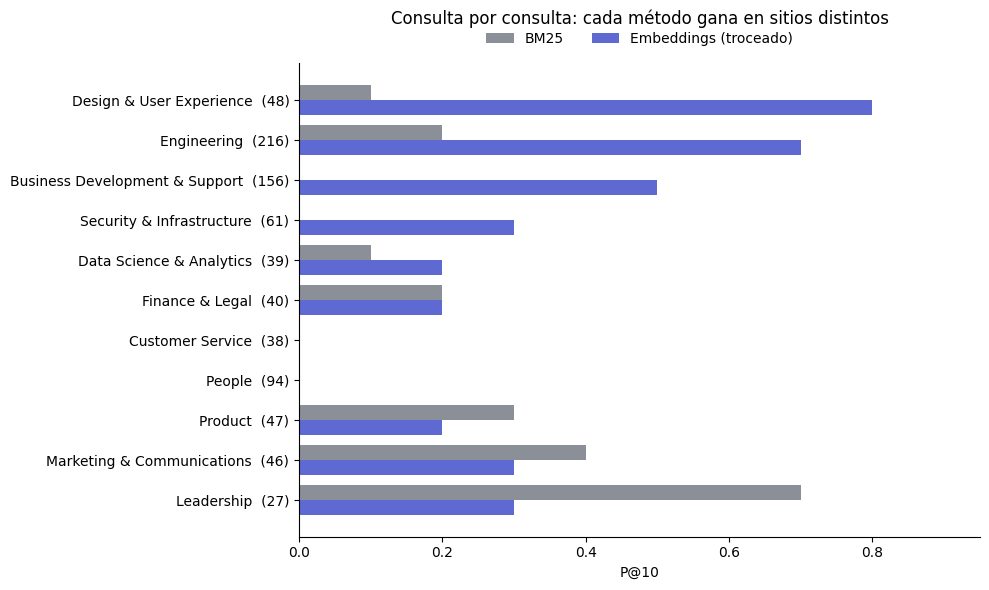

Embeddings gana en 5, pierde en 3, empata en 3


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
orden = cara_a_cara.sort_values("diferencia").index
posicion = np.arange(len(orden))
alto = 0.38

ax.barh(posicion + alto / 2, cara_a_cara.loc[orden, "BM25"], alto,
        label="BM25", color=GRIS)
ax.barh(posicion - alto / 2, cara_a_cara.loc[orden, "Embeddings"], alto,
        label="Embeddings (troceado)", color=ACENTO)

ax.set_yticks(posicion, [f"{c}  ({int(cara_a_cara.loc[c, 'relevantes'])})" for c in orden])
ax.set_xlim(0, 0.95)
ax.set_xlabel("P@10")
ax.set_title("Consulta por consulta: cada método gana en sitios distintos", pad=28)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "bm25-vs-embeddings.png", dpi=140)
plt.show()

gana = (cara_a_cara["diferencia"] > 0).sum()
pierde = (cara_a_cara["diferencia"] < 0).sum()
empata = (cara_a_cara["diferencia"] == 0).sum()
print(f"Embeddings gana en {gana}, pierde en {pierde}, empata en {empata}")

### Qué se ve aquí — el resultado que justifica el paso 6

**Los embeddings no ganan en todo.**

**Donde arrasan** — justo las consultas donde BM25 sacaba cero o casi:

| Consulta | BM25 | Embeddings |
|---|---|---|
| Design & User Experience | 0,1 | **0,8** |
| Engineering | 0,2 | **0,7** |
| Business Development & Support | **0,0** | **0,5** |
| Security & Infrastructure | **0,0** | **0,3** |

`Business Development` y `Security & Infrastructure` pasan de no recuperar
absolutamente nada a acertar la mitad y un tercio del top 10. Ese es exactamente
el problema que los embeddings prometían resolver, y lo resuelven.

**Donde pierden:**

| Consulta | BM25 | Embeddings |
|---|---|---|
| Leadership | **0,7** | 0,3 |
| Marketing & Communications | **0,4** | 0,3 |
| Product | **0,3** | 0,2 |

`Leadership` es el caso más claro: BM25 encontraba cuatro `Director of …`
seguidos porque la consulta hablaba de dirigir equipos y las ofertas decían
literalmente eso. **Cuando las palabras coinciden, contar palabras es difícil de
mejorar** — y el embedding, al comprimir todo a 384 números, pierde precisión
sobre esa señal tan directa.

**Donde fallan los dos:** `People` y `Customer Service` siguen en 0,0.

Ese último dato conviene leerlo junto al paso 3, donde se vio que la consulta de
`Customer Service` **sí recuperaba puestos de atención al cliente**, pero de Seek
en lugar de Booking. Que ahora fallen los dos métodos apunta a que **el límite
está en la verdad de referencia, no en los buscadores**.

> **Esto es lo que justifica el paso 6.** Si cada método gana en consultas
> distintas, combinarlos debería superar a ambos. No es una idea bonita: es lo
> que dicen estos números.

---

# 5. Lo que cuesta

Los embeddings ganan en calidad. Conviene poner al lado lo que se paga.

In [10]:
def segundos_de(nombre):
    meta = CACHE / f"{nombre}.json"
    return json.loads(meta.read_text())["segundos"] if meta.exists() else float("nan")


coste = pd.DataFrame([
    {"método": "BM25", "preparar_s": 1.7, "ms_consulta": 54.9,
     "vectores": 0, "memoria_MB": 0.0},
    {"método": "Embeddings truncado", "preparar_s": segundos_de("limpio_trunc"),
     "ms_consulta": comparativa.loc["A · limpio, truncado", "ms_consulta"],
     "vectores": len(corpus), "memoria_MB": round(vectores_a.nbytes / 1024**2, 1)},
    {"método": "Embeddings troceado", "preparar_s": segundos_de(f"trozos_{VENTANA}_{SOLAPE}"),
     "ms_consulta": comparativa.loc["D · troceado (mejor trozo)", "ms_consulta"],
     "vectores": len(trozos), "memoria_MB": round(vectores_d.nbytes / 1024**2, 1)},
]).set_index("método")
coste

,preparar_s,ms_consulta,vectores,memoria_MB
método,,,,
BM25,1.7,54.9,0,0.0
Embeddings truncado,278.1,15.6,10145,14.9
Embeddings troceado,774.2,21.3,32629,47.8


### Qué se ve aquí — y por qué pgvector sigue sin hacer falta

**Preparar el índice es entre 150 y 550 veces más caro** con embeddings que con
BM25: de 1,7 segundos a varios minutos. Es un coste de una sola vez, pero real —
y crece con el corpus.

**Buscar, en cambio, es más barato**: unos 28 ms por consulta con el troceado
frente a los 55 ms de BM25, pese a comparar contra 32 629 vectores en lugar de
10 145 documentos. Una multiplicación de matrices en NumPy es muy eficiente.

Ese número responde a la pregunta que el plan del proyecto dejó abierta:

> **pgvector sigue sin hacer falta.** Con 28 ms por consulta y 48 MB de vectores
> en memoria, una base de datos vectorial no resolvería ningún problema que exista
> hoy. Tendría sentido a partir de millones de documentos, o si hiciera falta
> persistir y compartir el índice entre procesos — que es justo el escenario del
> proyecto 6, cuando esto se despliegue.
>
> Montarlo ahora sería añadir infraestructura a un problema que no está.

In [11]:
resumen = pd.DataFrame([
    {"método": "Aleatorio (control)", "P@10": 0.0071, "MRR": 0.0366,
     "nDCG@10": 0.0075, "R@100": 0.0102},
    {"método": "BM25", **BM25},
    {"método": "Embeddings (truncado)",
     **{m: comparativa.loc["A · limpio, truncado", m]
        for m in ("P@10", "MRR", "nDCG@10", "R@100")}},
    {"método": "Embeddings (troceado)",
     **{m: comparativa.loc["D · troceado (mejor trozo)", m]
        for m in ("P@10", "MRR", "nDCG@10", "R@100")}},
]).set_index("método")

resumen.to_parquet(PROCESADO / "resultados_embeddings.parquet")
mejor.to_parquet(PROCESADO / "embeddings_por_consulta.parquet")
np.save(PROCESADO / "vectores_trozos.npy", vectores_d)
np.save(PROCESADO / "trozo_de_oferta.npy", de_oferta)

print(resumen.round(4).to_string())

                         P@10     MRR  nDCG@10   R@100
método                                                
Aleatorio (control)    0.0071  0.0366   0.0075  0.0102
BM25                   0.1818  0.3245   0.1812  0.2134
Embeddings (truncado)  0.2545  0.2642   0.2233  0.2062
Embeddings (troceado)  0.3182  0.4820   0.3115  0.2589


---

# Resumen

## Resultados

| Método | P@10 | MRR | nDCG@10 | R@100 |
|---|---|---|---|---|
| Aleatorio (control) | 0,007 | 0,037 | 0,008 | 0,010 |
| BM25 | 0,182 | 0,325 | 0,181 | 0,213 |
| Embeddings (truncado) | 0,255 | 0,264 | 0,223 | 0,206 |
| **Embeddings (troceado)** | **0,318** | **0,482** | **0,312** | **0,259** |

**La búsqueda semántica supera a BM25 en un 75 %** en P@10, y en MRR casi lo
duplica.

## Los cinco hallazgos

1. **El límite del modelo era la mitad de lo que supuse.** `all-MiniLM-L6-v2`
   corta a 256 tokens ≈ 192 palabras, no a 512. Con el número correcto, las
   ofertas que no caben no son el 49,4 % sino **el 83,1 %**.

2. **Trocear es la decisión que más pesa**: +25 % sobre truncar. Consecuencia
   directa de lo anterior — si cinco de cada seis ofertas no caben, truncar tira
   la mayor parte del corpus.

3. **Limpiar la plantilla corporativa sirvió, y hay dos pruebas independientes.**
   +17 % en embeddings y +18 % en BM25. Dos métodos que no se parecen en nada
   coinciden.

4. **Añadir el título del puesto empeora el resultado** (−18 %). Tengo una
   hipótesis —desplaza texto útil fuera de una ventana ya muy corta, y muchos
   títulos son genéricos— pero **no la he comprobado**.

5. **Buscar es barato; preparar el índice es caro.** 28 ms por consulta con
   32 629 vectores frente a 55 ms de BM25, a cambio de 16 minutos de codificación
   inicial.

## Un tropiezo del entorno

En Windows, **importar `pandas` antes que `torch` rompe torch** con
`WinError 1114` al cargar `c10.dll` — conflicto entre las DLL de OpenMP de ambas.
La solución es importar `sentence-transformers` en primer lugar. Reordenar esas
líneas «para dejarlas bonitas» rompe el cuaderno.

## Lo que esto decide

**pgvector sigue sin hacer falta.** 28 ms por consulta y 48 MB de vectores no son
un problema que una base de datos vectorial resuelva. Tendrá sentido en el
proyecto 6, cuando haya que persistir el índice y compartirlo entre procesos.

## Siguiente paso

Los dos métodos ganan en consultas **distintas**: los embeddings arrasan donde
BM25 sacaba cero, y BM25 sigue siendo mejor en `Leadership`, `Marketing` y
`Product`, donde las palabras de la consulta aparecen literalmente.

**Eso es exactamente la condición para que una combinación funcione.** El paso 6
lo comprobará.
